# Advanced Player Performance & Market Analysis (FIFA 22 Dataset)

This notebook performs advanced exploratory data analysis and visualization on FIFA 22 player data, with a focus on player performance, market value, wages, age profile, positions, and league comparisons.

**Assignment scope**
- Dataset: FIFA 22 player dataset
- Main filter: English Premier League, Spanish La Liga, German Bundesliga, Italian Serie A, and French Ligue 1
- Outputs: dataframe screenshots, shape/summary tables, all visualizations saved as report-ready PNG files
- Libraries: `pandas`, `numpy`, `matplotlib`, `seaborn`

## 1. Setup and Configuration

The constants below control the input dataset path and output image folder. The loader supports CSV, Excel, and zipped CSV/Excel files so the notebook can run with either the assignment CSV or the provided zipped workbook.

In [1]:
import io
import os
import zipfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# -----------------------------
# Global styling
# -----------------------------
sns.set_theme(style="whitegrid", context="notebook", palette="viridis")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["font.size"] = 10

# -----------------------------
# Paths
# -----------------------------
DATA_PATH = Path(r"C:\Users\Biplob\Downloads\Career Mode female player datasets - FIFA 16-22.xlsx.zip")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# If True, the notebook stops when the top-five league filter is empty.
# If False, it warns and falls back to all FIFA 22 players so every visualization still renders.
STRICT_TOP5_FILTER = False

TOP_5_LEAGUE_ALIASES = {
    "English Premier League": ["English Premier League", "Premier League"],
    "Spanish La Liga": ["Spanish La Liga", "Spain Primera Division", "La Liga", "Primera Division"],
    "German Bundesliga": ["German 1. Bundesliga", "German Bundesliga", "Bundesliga"],
    "Italian Serie A": ["Italian Serie A", "Serie A"],
    "French Ligue 1": ["French Ligue 1", "Ligue 1", "France Ligue 1"],
}

TOP_5_LEAGUE_LOOKUP = {
    alias.lower(): canonical
    for canonical, aliases in TOP_5_LEAGUE_ALIASES.items()
    for alias in aliases
}

## 2. Utility Functions

These helpers handle loading, cleaning, feature engineering, and image exports for both tables and plots.

In [2]:
def load_data(path=DATA_PATH, fifa_sheet="FIFA 22"):
    """Load FIFA data from CSV, Excel, or zipped CSV/Excel sources."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Dataset not found: {path}")

    suffix = path.suffix.lower()

    if suffix == ".csv":
        return pd.read_csv(path)

    if suffix in [".xlsx", ".xls"]:
        return pd.read_excel(path, sheet_name=fifa_sheet)

    if suffix == ".zip":
        with zipfile.ZipFile(path) as zf:
            names = [name for name in zf.namelist() if not name.endswith("/")]
            preferred = [name for name in names if "22" in name or "FIFA 22" in name]
            target = preferred[0] if preferred else names[0]
            raw = io.BytesIO(zf.read(target))

        if target.lower().endswith(".csv"):
            return pd.read_csv(raw)
        if target.lower().endswith((".xlsx", ".xls")):
            xl = pd.ExcelFile(raw)
            sheet = fifa_sheet if fifa_sheet in xl.sheet_names else xl.sheet_names[-1]
            return pd.read_excel(xl, sheet_name=sheet)

        raise ValueError(f"Unsupported file inside zip: {target}")

    raise ValueError(f"Unsupported dataset format: {path.suffix}")


def normalize_columns(df):
    """Standardize common FIFA column names from different dataset versions."""
    df = df.copy()
    df.columns = [str(col).strip() for col in df.columns]

    rename_map = {
        "Name": "short_name",
        "LongName": "long_name",
        "Overall": "overall",
        "Potential": "potential",
        "Value": "value_eur",
        "Value (?)": "value_eur",
        "Wage": "wage_eur",
        "Wage (?)": "wage_eur",
        "Age": "age",
        "Club": "club_name",
        "Club Name": "club_name",
        "League": "league_name",
        "League Name": "league_name",
        "Position": "player_positions",
        "Positions": "player_positions",
    }
    return df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})


def money_to_number(series):
    """Convert money strings such as ?110.5M, ?950K, or raw numeric values to EUR."""
    if pd.api.types.is_numeric_dtype(series):
        return pd.to_numeric(series, errors="coerce")

    cleaned = (
        series.astype(str)
        .str.replace("?", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.strip()
    )

    multipliers = np.select(
        [cleaned.str.endswith("M", na=False), cleaned.str.endswith("K", na=False)],
        [1_000_000, 1_000],
        default=1,
    )
    numeric = pd.to_numeric(cleaned.str.replace(r"[MK]$", "", regex=True), errors="coerce")
    return numeric * multipliers


def save_df_as_image(df, filename, title=None, max_rows=12, max_cols=8, figsize=(12, 4)):
    """Save a dataframe-like output as a PNG image for report submission."""
    output_path = OUTPUT_DIR / filename
    table_df = df.copy()

    if isinstance(table_df, pd.Series):
        table_df = table_df.to_frame()

    table_df = table_df.iloc[:max_rows, :max_cols]
    table_df = table_df.round(2)

    fig, ax = plt.subplots(figsize=figsize)
    ax.axis("off")
    if title:
        ax.set_title(title, fontsize=14, fontweight="bold", pad=12)

    table = ax.table(
        cellText=table_df.values,
        colLabels=table_df.columns,
        rowLabels=table_df.index,
        loc="center",
        cellLoc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1, 1.35)

    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_text_props(weight="bold", color="white")
            cell.set_facecolor("#2E86AB")
        elif row % 2 == 0:
            cell.set_facecolor("#F4F7FA")

    fig.tight_layout()
    fig.savefig(output_path, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    return output_path


def save_shape_as_image(df, filename="shape.png"):
    """Save dataset shape as a compact table image."""
    shape_df = pd.DataFrame({"Metric": ["Rows", "Columns"], "Value": [df.shape[0], df.shape[1]]})
    return save_df_as_image(shape_df, filename, title="Dataset Shape", max_rows=2, max_cols=2, figsize=(4, 2))


def save_plot(filename):
    """Save the active matplotlib figure to the output folder."""
    output_path = OUTPUT_DIR / filename
    plt.tight_layout()
    plt.savefig(output_path, bbox_inches="tight", facecolor="white")
    plt.show()
    return output_path


def clean_data(df, strict_top5=STRICT_TOP5_FILTER):
    """Clean the FIFA 22 data and filter to top-five European leagues when available."""
    df = normalize_columns(df)
    required = ["short_name", "overall", "potential", "value_eur", "wage_eur", "age", "player_positions"]
    missing_required = [col for col in required if col not in df.columns]
    if missing_required:
        raise KeyError(f"Missing required columns: {missing_required}")

    df = df.copy()
    df["value_eur"] = money_to_number(df["value_eur"])
    df["wage_eur"] = money_to_number(df["wage_eur"])

    numeric_cols = ["overall", "potential", "age", "value_eur", "wage_eur", "height_cm", "weight_kg"]
    for col in [col for col in numeric_cols if col in df.columns]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        if df[col].isna().any():
            df[col] = df[col].fillna(df[col].median())

    text_cols = ["short_name", "long_name", "club_name", "league_name", "player_positions", "club_position", "nationality_name"]
    for col in [col for col in text_cols if col in df.columns]:
        df[col] = df[col].fillna("Unknown")

    df["value_millions"] = df["value_eur"] / 1_000_000
    df["wage_thousands"] = df["wage_eur"] / 1_000
    df["primary_position"] = df["player_positions"].astype(str).str.split(",").str[0].str.strip()

    if "league_name" in df.columns:
        normalized_league = df["league_name"].astype(str).str.strip().str.lower()
        df["league_group"] = normalized_league.map(TOP_5_LEAGUE_LOOKUP)
        filtered = df[df["league_group"].notna()].copy()
    else:
        filtered = pd.DataFrame(columns=df.columns)

    if filtered.empty:
        message = (
            "No players matched the top-five league filter. The provided female FIFA 22 workbook "
            "has league_name missing for all rows. Using all FIFA 22 players as a fallback so the "
            "notebook remains executable; set STRICT_TOP5_FILTER=True to enforce the assignment filter."
        )
        if strict_top5:
            raise ValueError(message)
        warnings.warn(message)
        filtered = df.copy()
        filtered["league_group"] = np.where(
            filtered.get("league_name", "Unknown").astype(str).eq("Unknown"),
            "League Not Available",
            filtered.get("league_name", "Unknown"),
        )

    return filtered.reset_index(drop=True)


def feature_engineering(df):
    """Create performance, value-efficiency, and age-segment features."""
    df = df.copy()
    df["performance_index"] = (df["overall"] + df["potential"]) / 2
    df["value_to_wage_ratio"] = np.where(df["wage_thousands"] > 0, df["value_millions"] / df["wage_thousands"], np.nan)
    df["age_group"] = pd.cut(
        df["age"],
        bins=[-np.inf, 22, 30, np.inf],
        labels=["Young", "Prime", "Veteran"],
    )
    return df


def add_insight(text):
    display(Markdown(f"**Insight:** {text}"))

## 3. Data Loading and Initial Inspection

This section loads the FIFA 22 dataset and exports the required inspection screenshots: `head.png`, `shape.png`, and `describe.png`.

In [3]:
raw_df = load_data(DATA_PATH)

print("First five rows:")
display(raw_df.head())

print("Dataset shape:", raw_df.shape)

print("Dataset info:")
raw_df.info()

print("Summary statistics:")
display(raw_df.describe(include="all"))

save_df_as_image(raw_df.head(), "head.png", title="FIFA 22 Dataset Head", max_rows=5, max_cols=8, figsize=(14, 3.5))
save_shape_as_image(raw_df, "shape.png")
save_df_as_image(raw_df.describe(include="all").fillna(""), "describe.png", title="FIFA 22 Summary Statistics", max_rows=12, max_cols=8, figsize=(14, 5))

print(f"Saved inspection images to: {OUTPUT_DIR.resolve()}")

First five rows:


,sofifa_id,player_url,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,...,lcb,cb,rcb,rb,gk,player_face_url,club_logo_url,club_flag_url,nation_logo_url,nation_flag_url
0,227246,https://sofifa.com/player/227246/lucy-bronze/2...,L. Bronze,Lucia Roberta Tough Bronze,"RB, CM",92,92,NaN,NaN,29,...,87+3,87+3,87+3,88+3,21+3,https://cdn.sofifa.com/players/227/246/22_120.png,NaN,NaN,https://cdn.sofifa.com/teams/113002/60.png,https://cdn.sofifa.com/flags/gb-eng.png
1,227316,https://sofifa.com/player/227316/wendie-renard...,W. Renard,Wéndèleine Thérèse Renard,CB,92,92,NaN,NaN,30,...,90+2,90+2,90+2,80+3,20+3,https://cdn.sofifa.com/players/227/316/22_120.png,NaN,NaN,https://cdn.sofifa.com/teams/113003/60.png,https://cdn.sofifa.com/flags/fr.png
2,233746,https://sofifa.com/player/233746/vivianne-mied...,V. Miedema,Vivianne Miedema,ST,92,93,NaN,NaN,24,...,52+3,52+3,52+3,57+3,24+3,https://cdn.sofifa.com/players/233/746/22_120.png,NaN,NaN,https://cdn.sofifa.com/teams/113011/60.png,https://cdn.sofifa.com/flags/nl.png
3,227125,https://sofifa.com/player/227125/samantha-kerr...,S. Kerr,Samantha May Kerr,"ST, LW",91,91,NaN,NaN,27,...,56+3,56+3,56+3,60+3,20+3,https://cdn.sofifa.com/players/227/125/22_120.png,NaN,NaN,https://cdn.sofifa.com/teams/112998/60.png,https://cdn.sofifa.com/flags/au.png
4,226301,https://sofifa.com/player/226301/alex-morgan/2...,A. Morgan,Alexandra Morgan Carrasco,ST,90,90,NaN,NaN,31,...,56+3,56+3,56+3,62+3,19+3,https://cdn.sofifa.com/players/226/301/22_120.png,NaN,NaN,https://cdn.sofifa.com/teams/113009/60.png,https://cdn.sofifa.com/flags/us.png


Dataset shape: (391, 110)
Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 391 entries, 0 to 390
Columns: 110 entries, sofifa_id to nation_flag_url
dtypes: datetime64[ns](1), float64(21), int64(46), object(42)
memory usage: 336.1+ KB
Summary statistics:


,sofifa_id,player_url,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,...,lcb,cb,rcb,rb,gk,player_face_url,club_logo_url,club_flag_url,nation_logo_url,nation_flag_url
count,391.000000,391,391,391,391,391.000000,391.000000,4.600000e+01,46.000000,391.000000,...,391,391,391,391,391,391,0.0,0.0,391,391
unique,NaN,391,391,391,124,NaN,NaN,NaN,NaN,NaN,...,134,134,134,106,48,391,NaN,NaN,17,17
top,NaN,https://sofifa.com/player/227246/lucy-bronze/2...,L. Bronze,Lucia Roberta Tough Bronze,GK,NaN,NaN,NaN,NaN,NaN,...,70+2,70+2,70+2,70+2,17+2,https://cdn.sofifa.com/players/227/246/22_120.png,NaN,NaN,https://cdn.sofifa.com/teams/113002/60.png,https://cdn.sofifa.com/flags/gb-eng.png
freq,NaN,1,1,1,48,NaN,NaN,NaN,NaN,NaN,...,12,12,12,15,49,1,NaN,NaN,23,23
mean,241580.636829,NaN,NaN,NaN,NaN,76.713555,79.511509,4.739674e+06,879.347826,27.002558,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,226177.000000,NaN,NaN,NaN,NaN,60.000000,66.000000,3.250000e+05,500.000000,18.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,227394.500000,NaN,NaN,NaN,NaN,73.000000,76.000000,2.525000e+06,500.000000,24.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,241526.000000,NaN,NaN,NaN,NaN,76.000000,79.000000,3.400000e+06,900.000000,27.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,248734.000000,NaN,NaN,NaN,NaN,81.000000,83.000000,4.875000e+06,1000.000000,30.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,264630.000000,NaN,NaN,NaN,NaN,92.000000,93.000000,2.700000e+07,2000.000000,38.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Saved inspection images to: C:\Users\Biplob\Desktop\pca\outputs


## 4. Data Cleaning

Cleaning steps:
- Standardize key column names across possible FIFA dataset versions
- Convert market value to millions of euros
- Convert wage to thousands of euros
- Fill missing numeric values using medians and missing text values with `Unknown`
- Filter to the top five leagues when league labels are available

In [4]:
cleaned_df = clean_data(raw_df)

print("Cleaned dataset shape:", cleaned_df.shape)
print("League groups included:")
display(cleaned_df["league_group"].value_counts().to_frame("player_count"))

display(cleaned_df[["short_name", "age", "overall", "potential", "value_millions", "wage_thousands", "league_group", "primary_position"]].head())

Cleaned dataset shape: (391, 114)
League groups included:


C:\Users\Biplob\AppData\Local\Temp\ipykernel_1476\3969532479.py:176: UserWarning: No players matched the top-five league filter. The provided female FIFA 22 workbook has league_name missing for all rows. Using all FIFA 22 players as a fallback so the notebook remains executable; set STRICT_TOP5_FILTER=True to enforce the assignment filter.
  warnings.warn(message)


,player_count
league_group,
League Not Available,391


,short_name,age,overall,potential,value_millions,wage_thousands,league_group,primary_position
0,L. Bronze,29,92,92,3.4,0.9,League Not Available,RB
1,W. Renard,30,92,92,3.4,0.9,League Not Available,CB
2,V. Miedema,24,92,93,3.4,0.9,League Not Available,ST
3,S. Kerr,27,91,91,3.4,0.9,League Not Available,ST
4,A. Morgan,31,90,90,3.4,0.9,League Not Available,ST


## 5. Feature Engineering

New features created:
- `performance_index`: average of overall and potential rating
- `value_to_wage_ratio`: market value in millions divided by weekly wage in thousands
- `age_group`: Young, Prime, or Veteran

In [5]:
df = feature_engineering(cleaned_df)

feature_cols = [
    "short_name", "age", "age_group", "overall", "potential",
    "performance_index", "value_millions", "wage_thousands",
    "value_to_wage_ratio", "league_group", "primary_position"
]
display(df[feature_cols].head())

,short_name,age,age_group,overall,potential,performance_index,value_millions,wage_thousands,value_to_wage_ratio,league_group,primary_position
0,L. Bronze,29,Prime,92,92,92.0,3.4,0.9,3.777778,League Not Available,RB
1,W. Renard,30,Prime,92,92,92.0,3.4,0.9,3.777778,League Not Available,CB
2,V. Miedema,24,Prime,92,93,92.5,3.4,0.9,3.777778,League Not Available,ST
3,S. Kerr,27,Prime,91,91,91.0,3.4,0.9,3.777778,League Not Available,ST
4,A. Morgan,31,Veteran,90,90,90.0,3.4,0.9,3.777778,League Not Available,ST


## 6. Visualization Functions

Each plotting function saves a report-ready PNG file using a clear filename.

In [6]:
def plot_top_overall(data):
    top = data.nlargest(15, "overall").sort_values("overall")
    plt.figure(figsize=(10, 7))
    sns.barplot(data=top, x="overall", y="short_name", hue="overall", palette="mako", legend=False)
    plt.title("Top 15 Players by Overall Rating")
    plt.xlabel("Overall Rating")
    plt.ylabel("Player")
    save_plot("top_15_overall.png")
    add_insight("The highest-rated players represent the strongest immediate sporting assets. Clubs can use this ranking to identify proven elite performers, while any unusually high-rated older players may require contract-risk review.")


def plot_top_value(data):
    top = data.nlargest(15, "value_millions").sort_values("value_millions")
    plt.figure(figsize=(10, 7))
    sns.barplot(data=top, x="value_millions", y="short_name", hue="value_millions", palette="crest", legend=False)
    plt.title("Top 15 Players by Market Value")
    plt.xlabel("Market Value (? millions)")
    plt.ylabel("Player")
    save_plot("top_15_value.png")
    add_insight("Market value tends to reward both current quality and future upside. Players at the top of this chart are expensive acquisition targets, but they may also protect resale value if they are young or still improving.")


def plot_top_wage(data):
    top = data.nlargest(15, "wage_thousands").sort_values("wage_thousands")
    plt.figure(figsize=(10, 7))
    sns.barplot(data=top, x="wage_thousands", y="short_name", hue="wage_thousands", palette="rocket", legend=False)
    plt.title("Top 15 Players by Wage")
    plt.xlabel("Weekly Wage (? thousands)")
    plt.ylabel("Player")
    save_plot("top_15_wage.png")
    add_insight("Wage leaders indicate where clubs have made the largest recurring salary commitments. Comparing this chart with overall rating helps identify whether compensation is aligned with on-field output.")


def plot_age_vs_overall(data):
    plt.figure(figsize=(9, 6))
    sns.regplot(data=data, x="age", y="overall", scatter_kws={"alpha": 0.65}, line_kws={"color": "crimson"})
    plt.title("Age vs Overall Rating")
    plt.xlabel("Age")
    plt.ylabel("Overall Rating")
    save_plot("age_vs_overall.png")
    add_insight("The regression line shows how overall rating changes through player age. Prime-age clusters usually reveal peak performance years, while young high-rating outliers signal premium talent development opportunities.")


def plot_wage_vs_overall(data):
    plot_data = data[data["wage_thousands"].notna() & (data["wage_thousands"] >= 0)]
    plt.figure(figsize=(9, 6))
    sns.regplot(data=plot_data, x="wage_thousands", y="overall", scatter_kws={"alpha": 0.65}, line_kws={"color": "crimson"})
    plt.title("Wage vs Overall Rating")
    plt.xlabel("Weekly Wage (? thousands)")
    plt.ylabel("Overall Rating")
    save_plot("wage_vs_overall.png")
    add_insight("A positive relationship suggests that wages generally reflect player quality. Points far above the line are efficient contracts, while points below it may indicate overpayment relative to current performance.")


def plot_value_vs_potential(data):
    plt.figure(figsize=(9, 6))
    sns.scatterplot(data=data, x="potential", y="value_millions", hue="age_group", style="age_group", s=80, alpha=0.8)
    plt.title("Market Value vs Potential by Age Group")
    plt.xlabel("Potential Rating")
    plt.ylabel("Market Value (? millions)")
    plt.legend(title="Age Group")
    save_plot("value_vs_potential_age_group.png")
    add_insight("Players with high potential and lower current value are attractive recruitment targets. Young players with strong potential often command higher prices because clubs are buying future performance and resale upside.")


def plot_performance_distribution(data):
    plt.figure(figsize=(9, 6))
    sns.histplot(data=data, x="performance_index", kde=True, bins=18, color="#2E86AB")
    plt.title("Distribution of Performance Index")
    plt.xlabel("Performance Index")
    plt.ylabel("Player Count")
    save_plot("performance_index_distribution.png")
    add_insight("The distribution shows the depth of quality in the selected player pool. A right-skewed tail highlights elite players, while the central mass represents the typical performance level available in the market.")


def plot_value_to_wage_ratio(data):
    plot_data = data.replace([np.inf, -np.inf], np.nan).dropna(subset=["value_to_wage_ratio"])
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=plot_data, x="value_to_wage_ratio", color="#6A994E")
    plt.title("Value-to-Wage Ratio")
    plt.xlabel("Value (? millions) / Wage (? thousands)")
    save_plot("value_to_wage_ratio_boxplot.png")
    add_insight("High ratio outliers are potentially undervalued contracts: strong market value for a relatively low wage. Low ratios may reflect expensive contracts, older players, or players whose wage exceeds market efficiency.")


def plot_avg_performance_by_league(data):
    league_perf = data.groupby("league_group", as_index=False)["performance_index"].mean().sort_values("performance_index", ascending=False)
    plt.figure(figsize=(10, 5))
    sns.barplot(data=league_perf, x="performance_index", y="league_group", hue="performance_index", palette="viridis", legend=False)
    plt.title("Average Performance Index by League")
    plt.xlabel("Average Performance Index")
    plt.ylabel("League")
    save_plot("league_comparison.png")
    add_insight("League-level averages compare squad quality across competitions. Higher averages suggest stronger concentration of talent, which can influence transfer pricing, scouting difficulty, and competitive intensity.")


def plot_wage_distribution_by_league(data):
    plt.figure(figsize=(11, 6))
    sns.boxplot(data=data, x="league_group", y="wage_thousands", palette="Set2")
    plt.title("Wage Distribution per League")
    plt.xlabel("League")
    plt.ylabel("Weekly Wage (? thousands)")
    plt.xticks(rotation=25, ha="right")
    save_plot("wage_distribution_per_league.png")
    add_insight("This boxplot compares salary structures across leagues. Wide boxes or long upper whiskers indicate greater wage inequality and a stronger presence of star contracts.")


def plot_age_distribution_by_league(data):
    plt.figure(figsize=(11, 6))
    sns.violinplot(data=data, x="league_group", y="age", palette="Pastel1", inner="quartile")
    plt.title("Age Distribution per League")
    plt.xlabel("League")
    plt.ylabel("Age")
    plt.xticks(rotation=25, ha="right")
    save_plot("age_distribution_per_league.png")
    add_insight("Age distributions reveal whether leagues lean toward development, peak-age talent, or veteran experience. A younger profile may imply stronger resale potential but more performance volatility.")


def plot_position_distribution(data):
    order = data["primary_position"].value_counts().index
    plt.figure(figsize=(11, 6))
    sns.countplot(data=data, y="primary_position", order=order, palette="cubehelix")
    plt.title("Position Distribution")
    plt.xlabel("Player Count")
    plt.ylabel("Primary Position")
    save_plot("position_distribution.png")
    add_insight("Position counts show the supply profile of the dataset. Scarcer positions with high average performance may carry stronger transfer leverage because replacement options are limited.")


def plot_avg_performance_by_position(data):
    pos_perf = data.groupby("primary_position", as_index=False)["performance_index"].mean().sort_values("performance_index", ascending=False)
    plt.figure(figsize=(11, 6))
    sns.barplot(data=pos_perf, x="performance_index", y="primary_position", hue="performance_index", palette="magma", legend=False)
    plt.title("Average Performance Index by Position")
    plt.xlabel("Average Performance Index")
    plt.ylabel("Primary Position")
    save_plot("avg_performance_by_position.png")
    add_insight("This chart highlights which positions have the strongest average quality. Recruitment teams can combine this view with scarcity to prioritize roles where elite performance is harder to find.")


def plot_correlation_heatmap(data):
    corr_cols = [
        "age", "overall", "potential", "value_millions", "wage_thousands",
        "performance_index", "value_to_wage_ratio", "pace", "shooting", "passing",
        "dribbling", "defending", "physic"
    ]
    corr_cols = [col for col in corr_cols if col in data.columns]
    corr_data = data[corr_cols].replace([np.inf, -np.inf], np.nan).dropna(axis=1, how="all")

    plt.figure(figsize=(11, 8))
    sns.heatmap(corr_data.corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0, linewidths=0.5)
    plt.title("Correlation Heatmap")
    save_plot("correlation_heatmap.png")
    add_insight("The heatmap identifies which attributes move together. Strong links between value, wage, overall, and potential confirm the economic importance of both current performance and expected future ability.")

## 7. Player Analysis

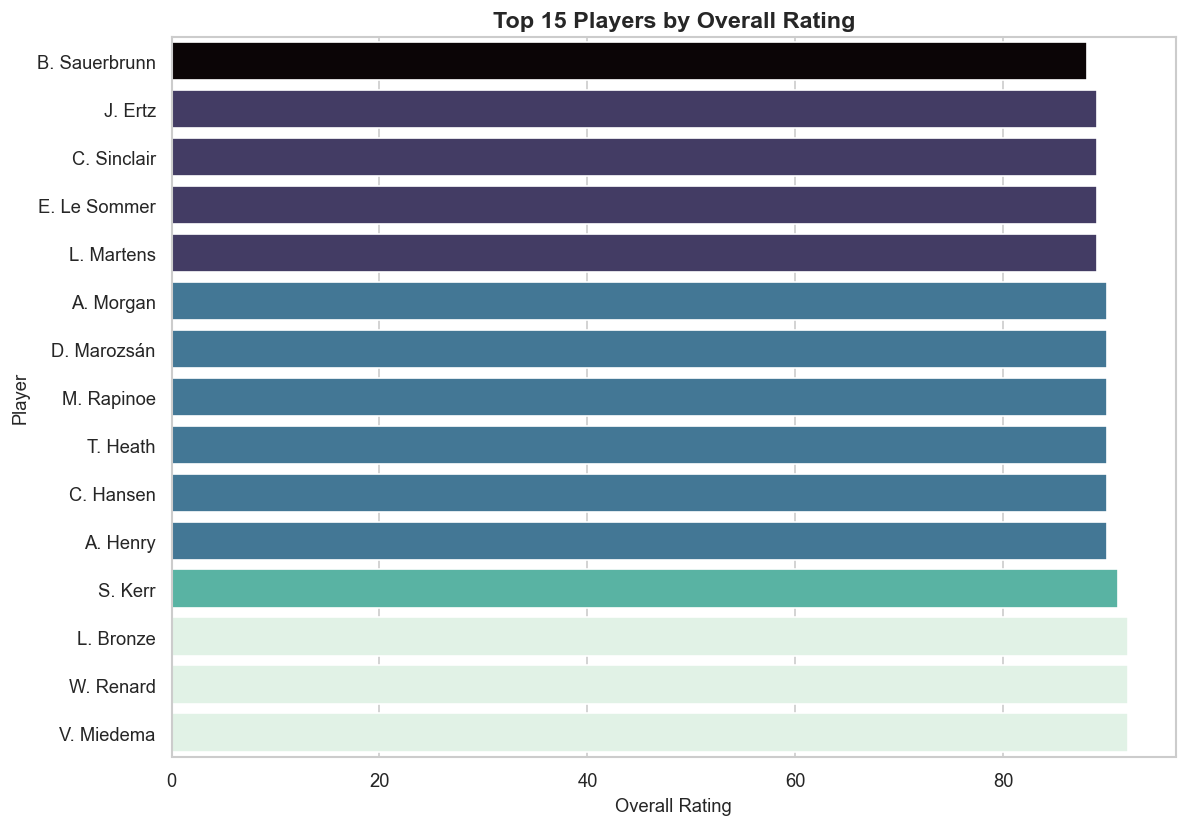

**Insight:** The highest-rated players represent the strongest immediate sporting assets. Clubs can use this ranking to identify proven elite performers, while any unusually high-rated older players may require contract-risk review.

In [7]:
plot_top_overall(df)

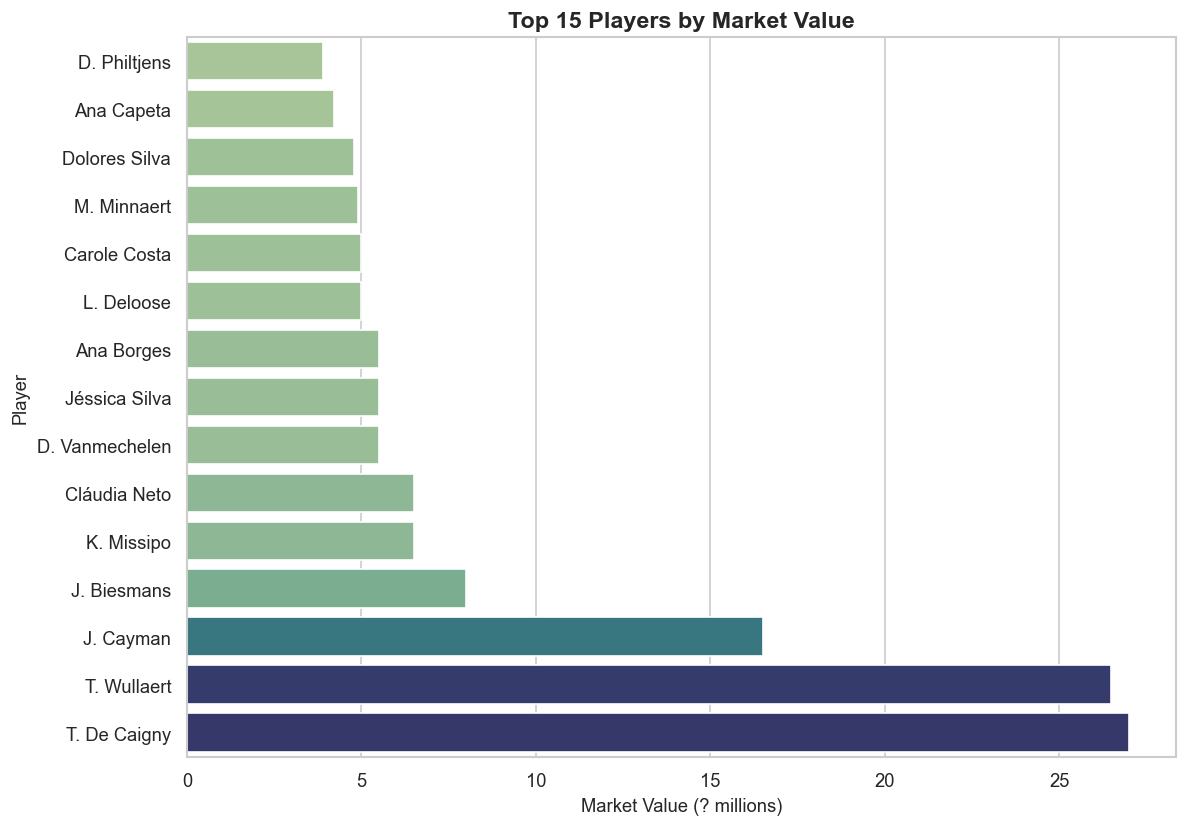

**Insight:** Market value tends to reward both current quality and future upside. Players at the top of this chart are expensive acquisition targets, but they may also protect resale value if they are young or still improving.

In [8]:
plot_top_value(df)

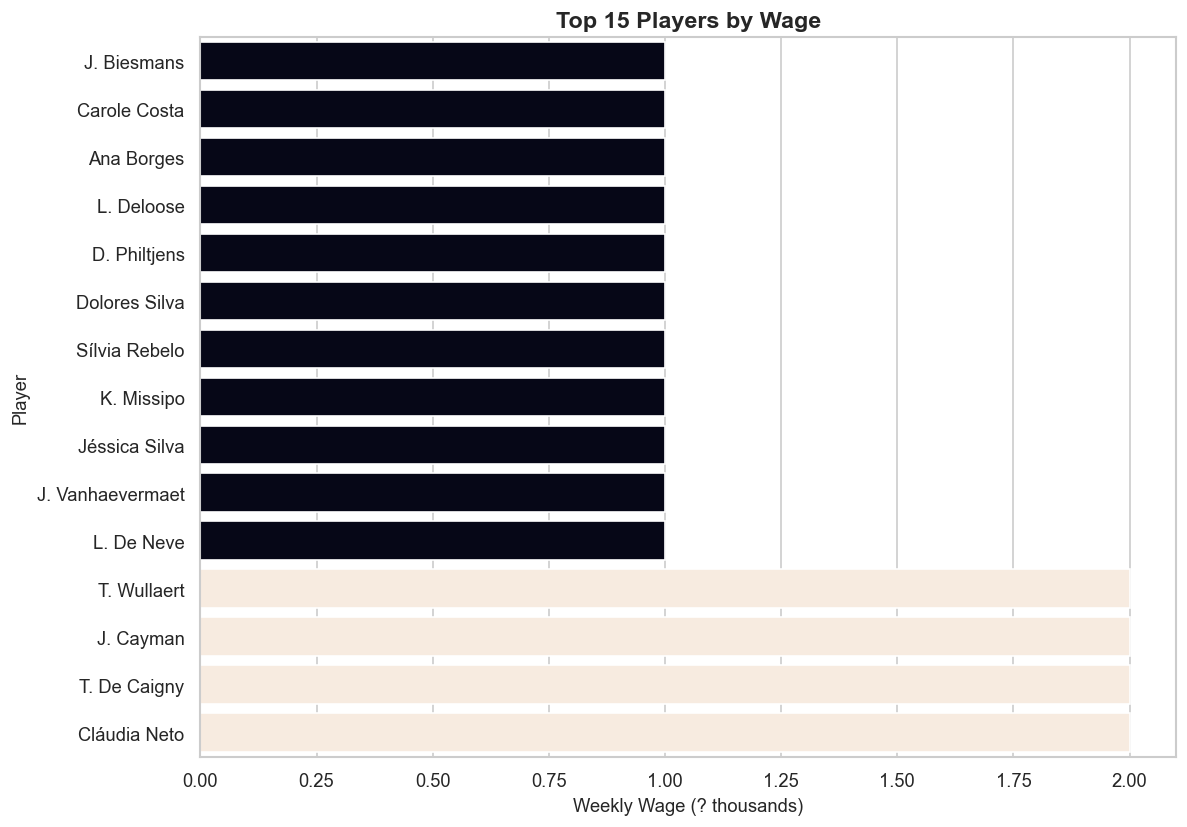

**Insight:** Wage leaders indicate where clubs have made the largest recurring salary commitments. Comparing this chart with overall rating helps identify whether compensation is aligned with on-field output.

In [9]:
plot_top_wage(df)

## 8. Relationship Analysis

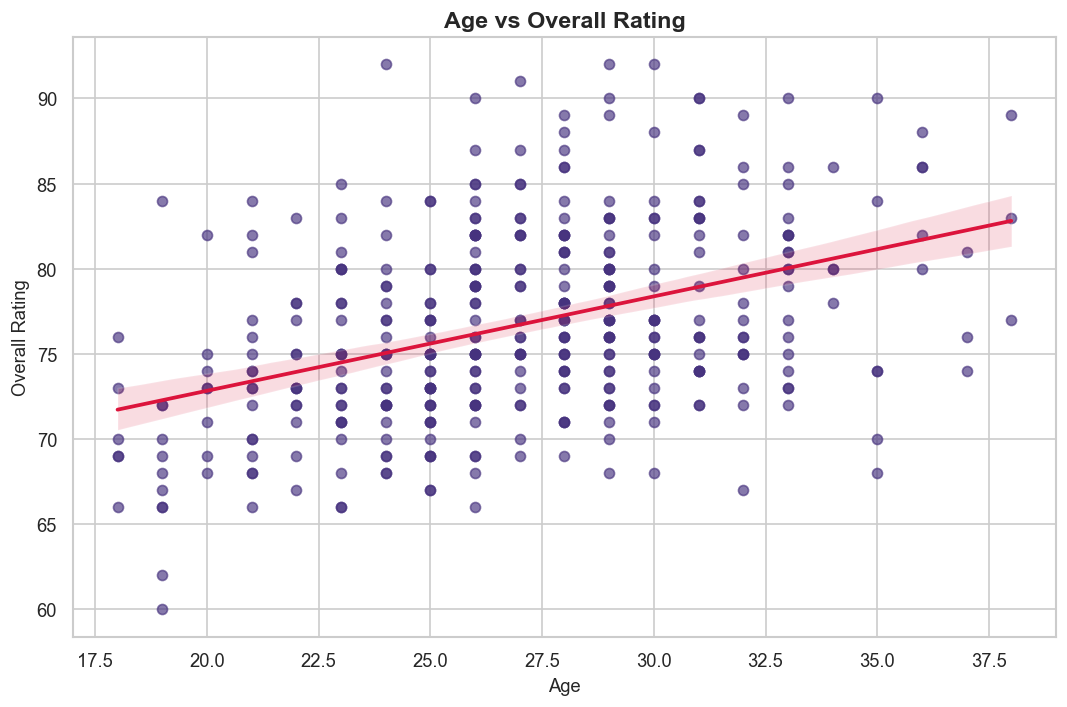

**Insight:** The regression line shows how overall rating changes through player age. Prime-age clusters usually reveal peak performance years, while young high-rating outliers signal premium talent development opportunities.

In [10]:
plot_age_vs_overall(df)

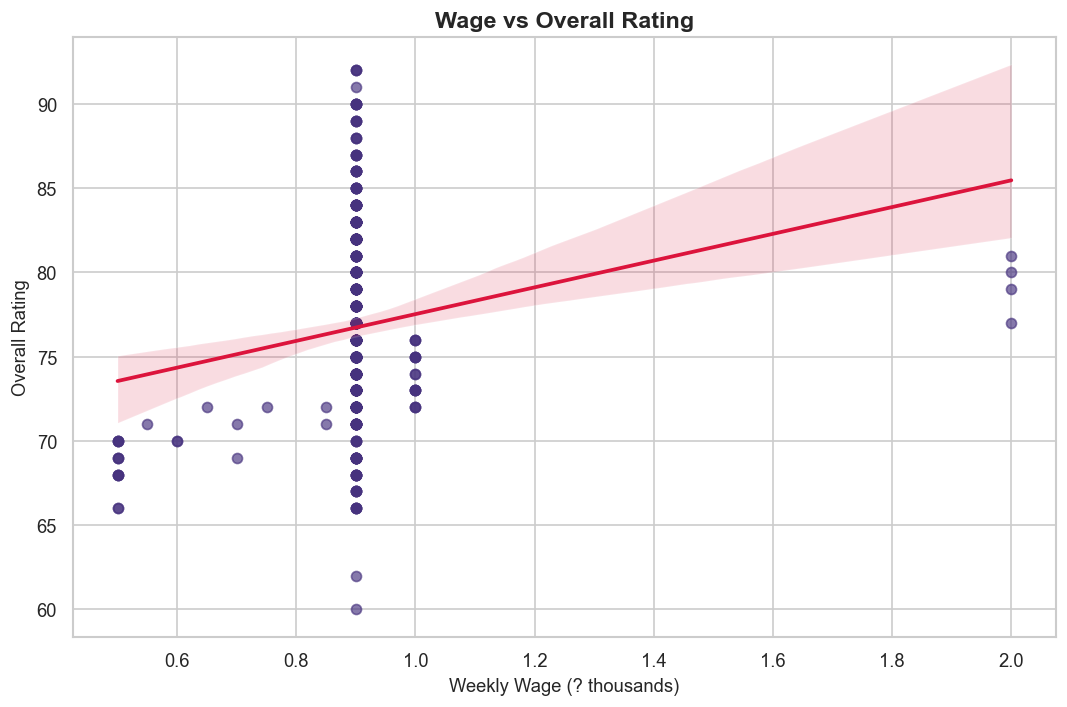

**Insight:** A positive relationship suggests that wages generally reflect player quality. Points far above the line are efficient contracts, while points below it may indicate overpayment relative to current performance.

In [11]:
plot_wage_vs_overall(df)

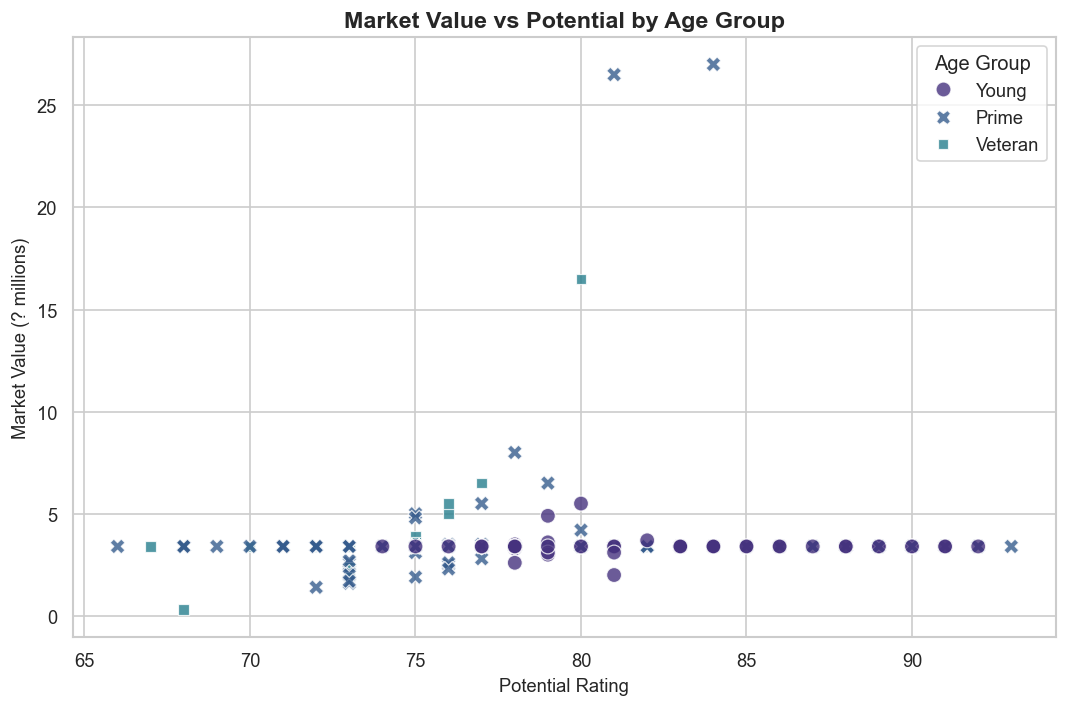

**Insight:** Players with high potential and lower current value are attractive recruitment targets. Young players with strong potential often command higher prices because clubs are buying future performance and resale upside.

In [12]:
plot_value_vs_potential(df)

## 9. Feature Insights

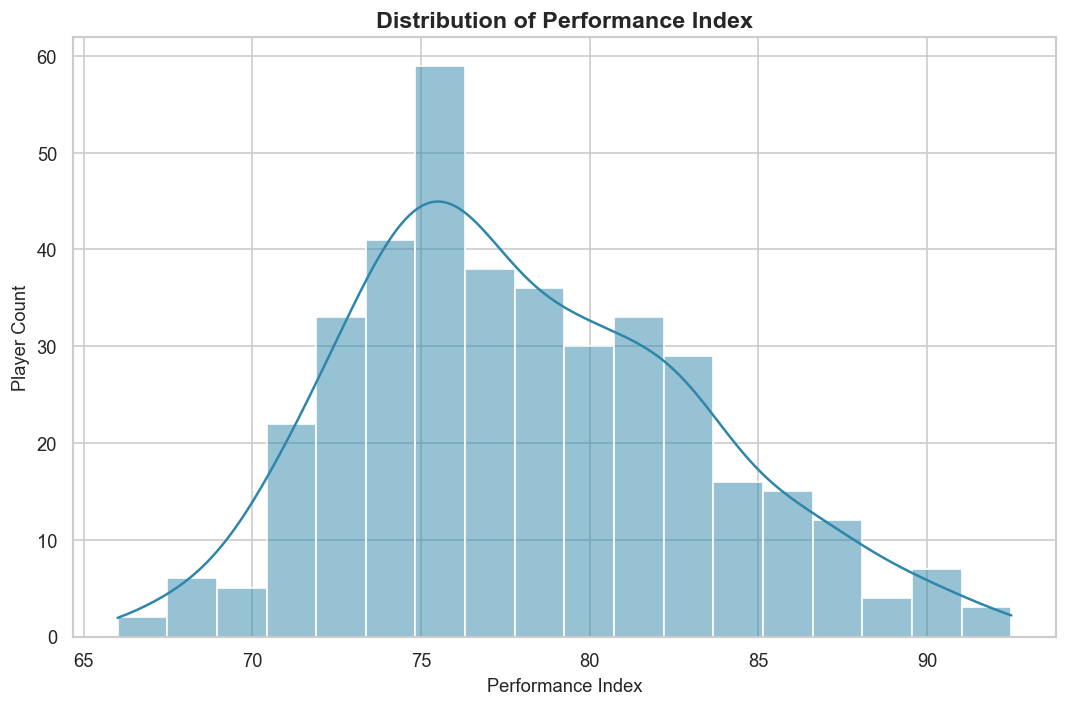

**Insight:** The distribution shows the depth of quality in the selected player pool. A right-skewed tail highlights elite players, while the central mass represents the typical performance level available in the market.

In [13]:
plot_performance_distribution(df)

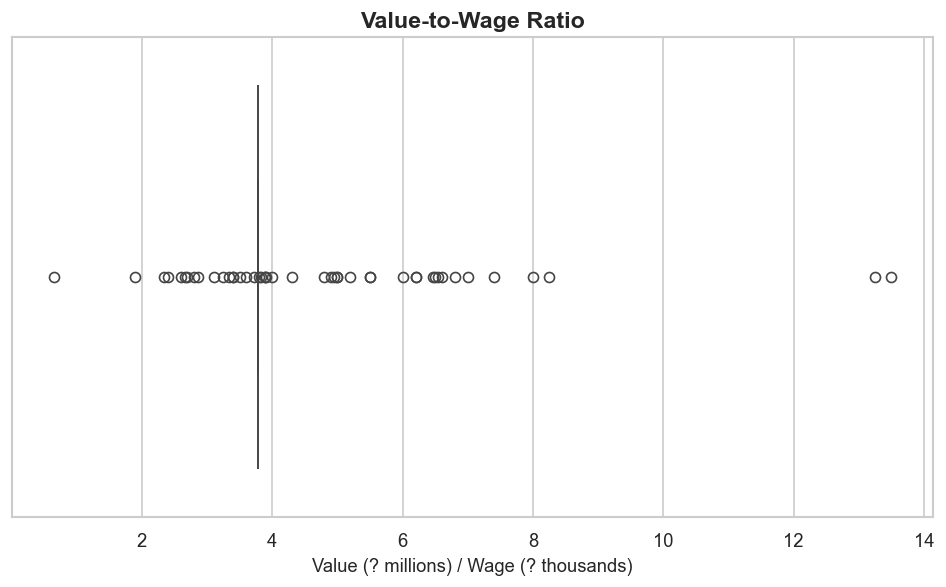

**Insight:** High ratio outliers are potentially undervalued contracts: strong market value for a relatively low wage. Low ratios may reflect expensive contracts, older players, or players whose wage exceeds market efficiency.

In [14]:
plot_value_to_wage_ratio(df)

## 10. League Analysis

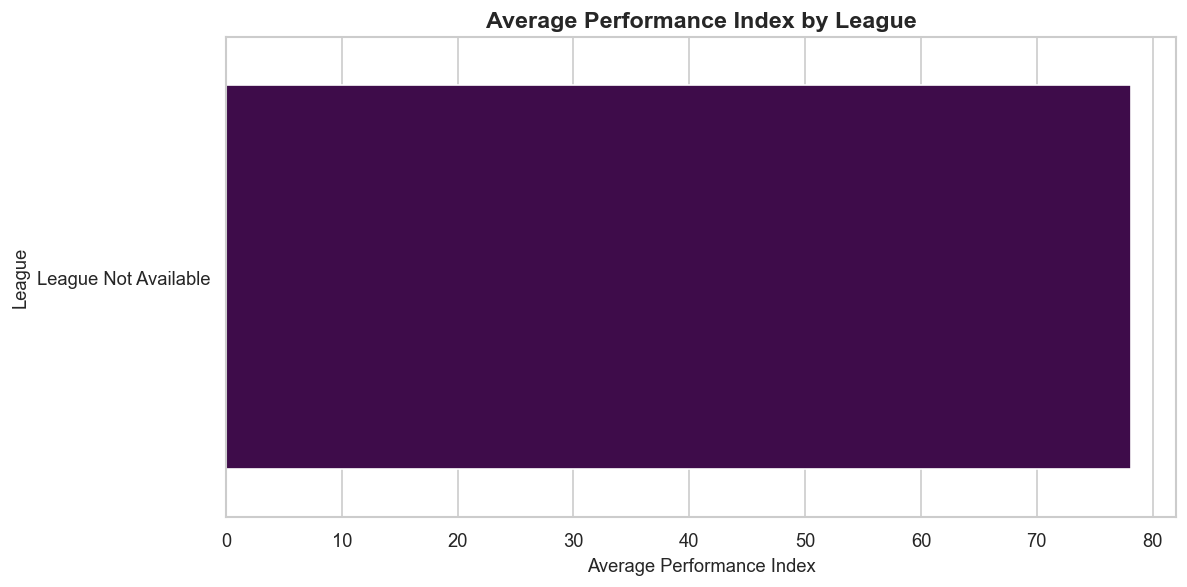

**Insight:** League-level averages compare squad quality across competitions. Higher averages suggest stronger concentration of talent, which can influence transfer pricing, scouting difficulty, and competitive intensity.

In [15]:
plot_avg_performance_by_league(df)

C:\Users\Biplob\AppData\Local\Temp\ipykernel_1476\170042442.py:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x="league_group", y="wage_thousands", palette="Set2")


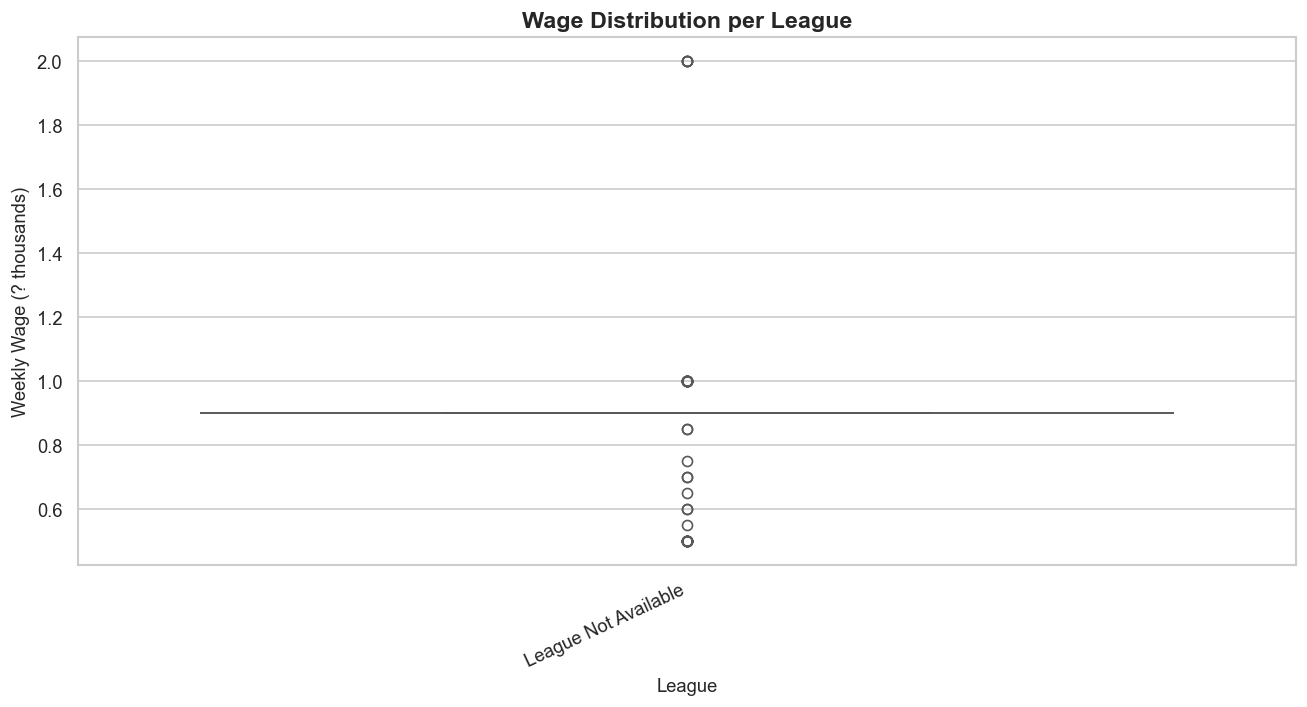

**Insight:** This boxplot compares salary structures across leagues. Wide boxes or long upper whiskers indicate greater wage inequality and a stronger presence of star contracts.

In [16]:
plot_wage_distribution_by_league(df)

C:\Users\Biplob\AppData\Local\Temp\ipykernel_1476\170042442.py:110: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x="league_group", y="age", palette="Pastel1", inner="quartile")


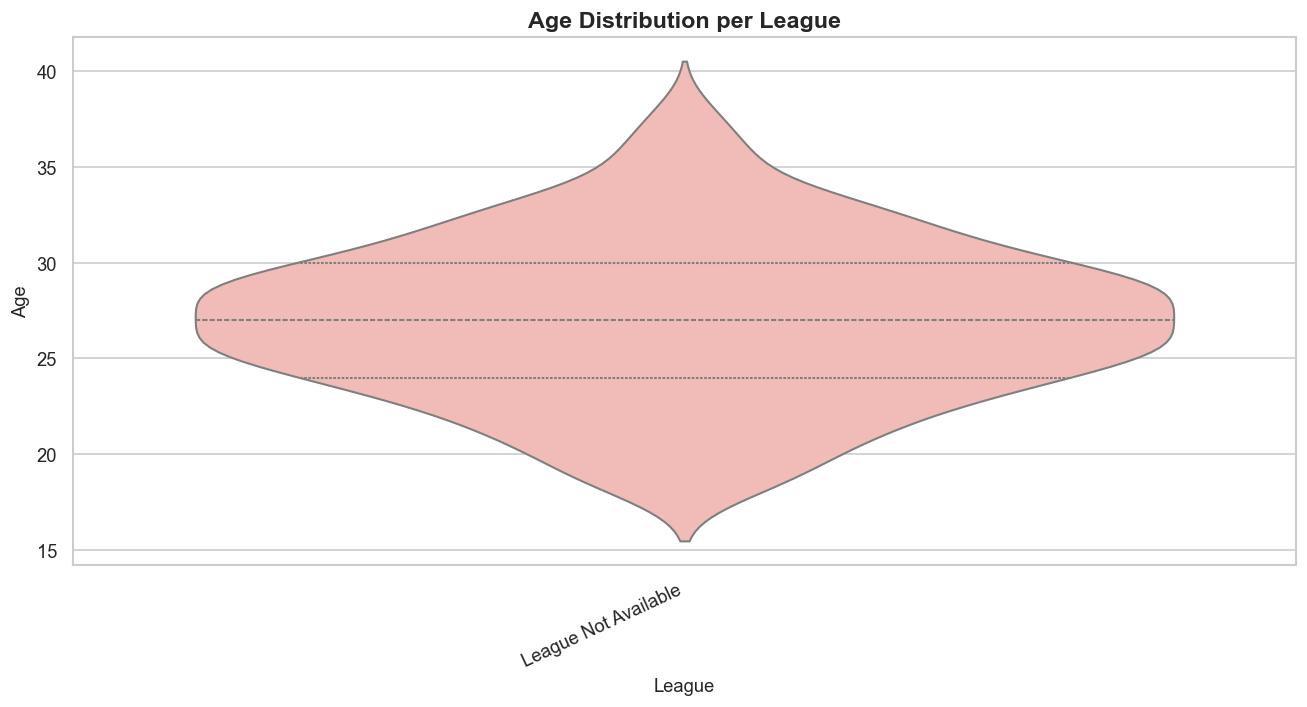

**Insight:** Age distributions reveal whether leagues lean toward development, peak-age talent, or veteran experience. A younger profile may imply stronger resale potential but more performance volatility.

In [17]:
plot_age_distribution_by_league(df)

## 11. Position Analysis

C:\Users\Biplob\AppData\Local\Temp\ipykernel_1476\170042442.py:122: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, y="primary_position", order=order, palette="cubehelix")


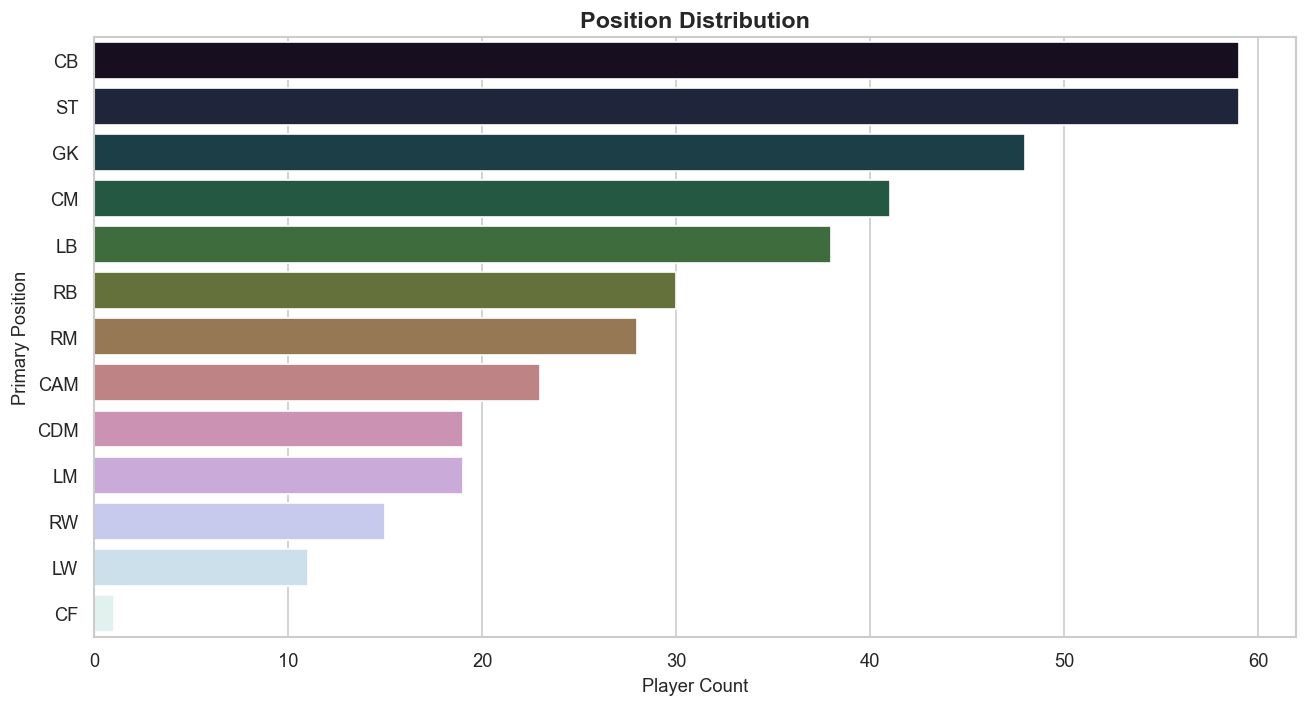

**Insight:** Position counts show the supply profile of the dataset. Scarcer positions with high average performance may carry stronger transfer leverage because replacement options are limited.

In [18]:
plot_position_distribution(df)

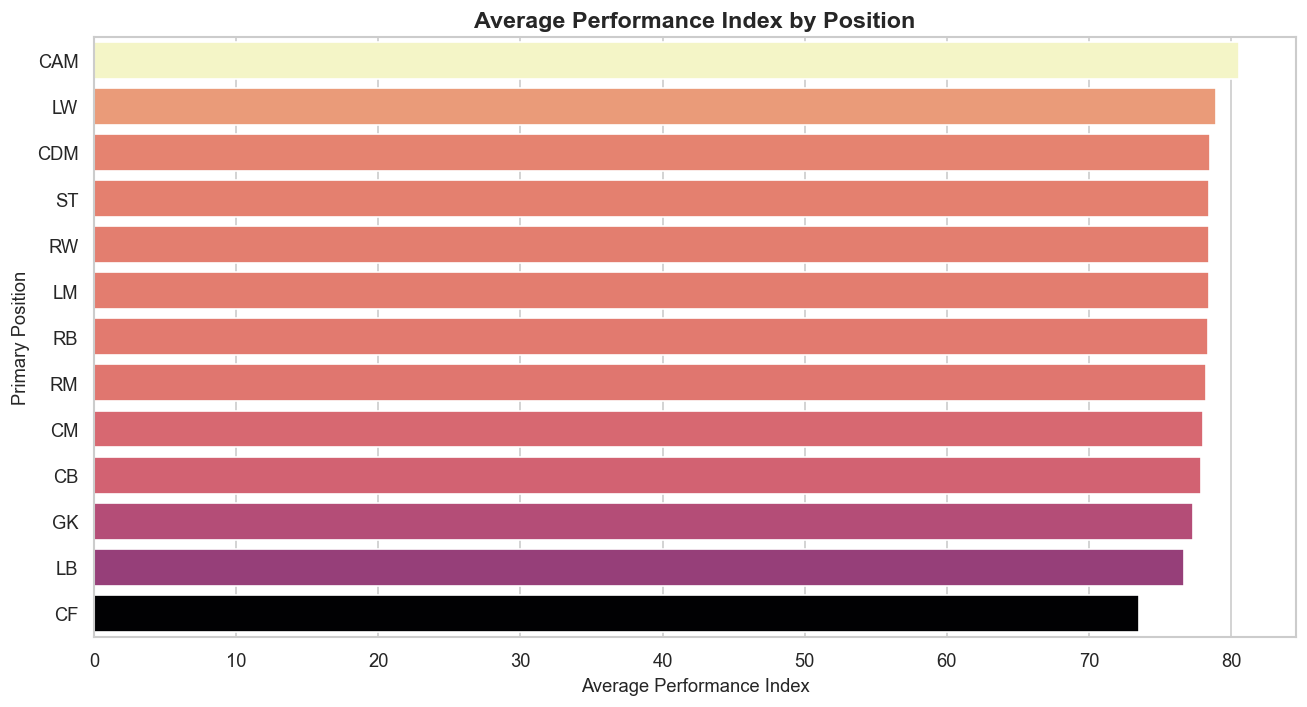

**Insight:** This chart highlights which positions have the strongest average quality. Recruitment teams can combine this view with scarcity to prioritize roles where elite performance is harder to find.

In [19]:
plot_avg_performance_by_position(df)

## 12. Correlation Analysis

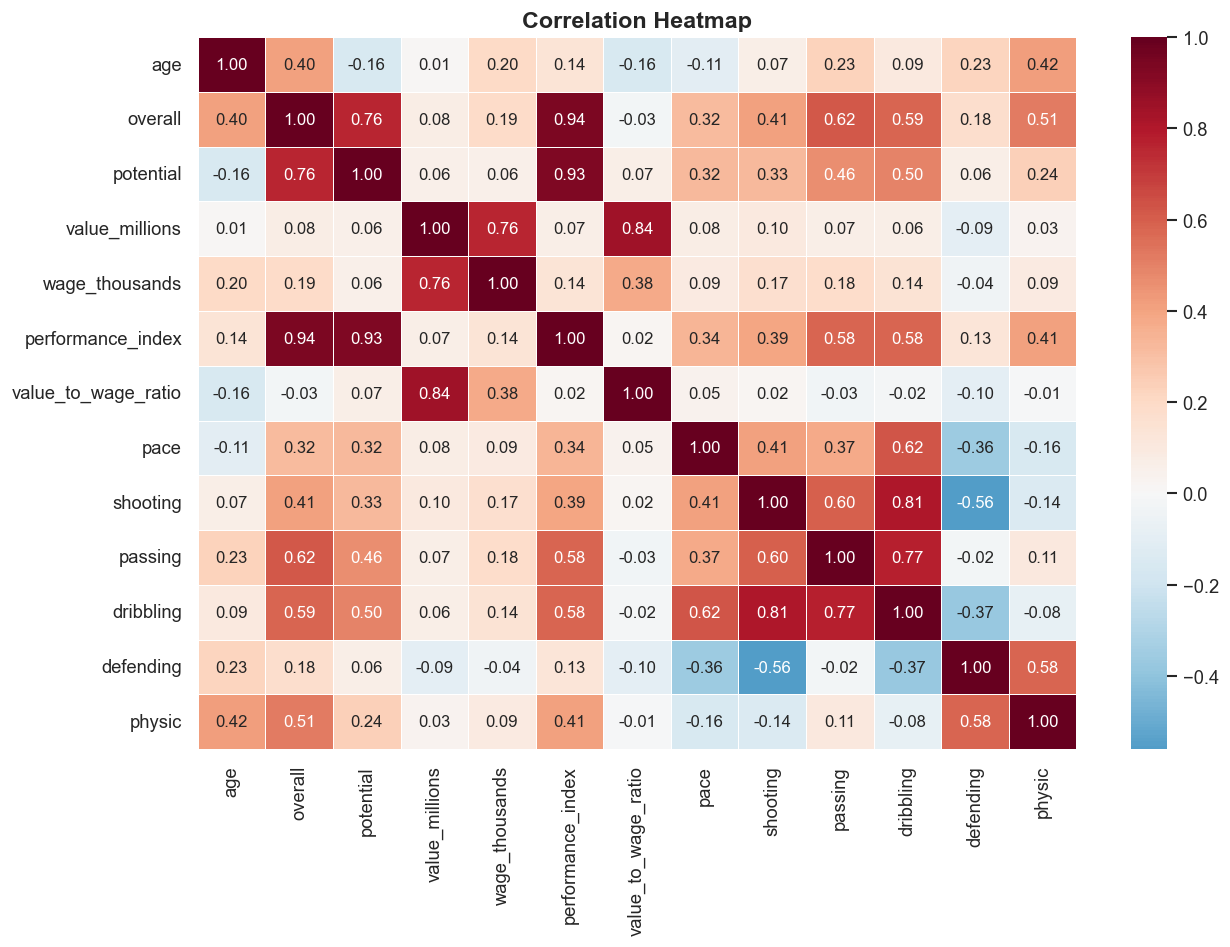

**Insight:** The heatmap identifies which attributes move together. Strong links between value, wage, overall, and potential confirm the economic importance of both current performance and expected future ability.

In [20]:
plot_correlation_heatmap(df)

## 13. Bonus Analysis: Undervalued Players and Future Stars

The bonus section identifies:
- **Top 5 undervalued players**: high performance index with relatively low wages
- **Top 5 future stars**: young players with the highest potential

In [21]:
def identify_undervalued_players(data, top_n=5):
    """Find high-performance players with relatively low wages."""
    candidates = data.copy()
    min_perf = candidates["performance_index"].quantile(0.70)
    candidates = candidates[candidates["performance_index"] >= min_perf]
    candidates["undervalued_score"] = candidates["performance_index"] / (candidates["wage_thousands"] + 1)
    cols = ["short_name", "age", "primary_position", "league_group", "overall", "potential", "performance_index", "wage_thousands", "value_millions", "undervalued_score"]
    return candidates.sort_values("undervalued_score", ascending=False)[cols].head(top_n)


def identify_future_stars(data, top_n=5):
    """Find young players with the highest potential."""
    cols = ["short_name", "age", "primary_position", "league_group", "overall", "potential", "performance_index", "value_millions", "wage_thousands"]
    return data[data["age_group"].eq("Young")].sort_values(["potential", "overall"], ascending=False)[cols].head(top_n)

undervalued_players = identify_undervalued_players(df)
future_stars = identify_future_stars(df)

print("Top 5 Undervalued Players")
display(undervalued_players)

print("Top 5 Future Stars")
display(future_stars)

save_df_as_image(undervalued_players, "top_5_undervalued_players.png", title="Top 5 Undervalued Players", max_rows=5, max_cols=10, figsize=(14, 3.5))
save_df_as_image(future_stars, "top_5_future_stars.png", title="Top 5 Future Stars", max_rows=5, max_cols=9, figsize=(14, 3.5))

add_insight("The undervalued list highlights salary-efficient performers, while the future-stars list emphasizes long-term talent. Together, they support two recruitment strategies: immediate value optimization and future asset growth.")

Top 5 Undervalued Players


,short_name,age,primary_position,league_group,overall,potential,performance_index,wage_thousands,value_millions,undervalued_score
2,V. Miedema,24,ST,League Not Available,92,93,92.5,0.9,3.4,48.684211
0,L. Bronze,29,RB,League Not Available,92,92,92.0,0.9,3.4,48.421053
1,W. Renard,30,CB,League Not Available,92,92,92.0,0.9,3.4,48.421053
3,S. Kerr,27,ST,League Not Available,91,91,91.0,0.9,3.4,47.894737
8,C. Hansen,26,RM,League Not Available,90,91,90.5,0.9,3.4,47.631579


Top 5 Future Stars


,short_name,age,primary_position,league_group,overall,potential,performance_index,value_millions,wage_thousands
47,L. Oberdorf,19,CB,League Not Available,84,92,88.0,3.4,0.9
64,M. Katoto,22,ST,League Not Available,83,91,87.0,3.4,0.9
81,E. Carpenter,21,RB,League Not Available,82,91,86.5,3.4,0.9
46,G. Gwinn,21,RM,League Not Available,84,90,87.0,3.4,0.9
296,H. Bennison,18,CAM,League Not Available,73,90,81.5,3.4,0.9


**Insight:** The undervalued list highlights salary-efficient performers, while the future-stars list emphasizes long-term talent. Together, they support two recruitment strategies: immediate value optimization and future asset growth.

## 14. Final Conclusion

This analysis connects sporting performance with market economics. The ranking charts identify elite players by rating, value, and wage; relationship plots show how age, wage, value, and potential interact; league and position views compare competitive contexts; and the correlation heatmap summarizes the strongest quantitative relationships.

For recruitment and squad planning, the most useful findings come from combining charts rather than reading any single visual alone. High-performance, low-wage players indicate efficient contracts, young high-potential players represent future resale upside, and league-level salary distributions help explain where market inflation is strongest.

All report-ready images are saved in the `outputs/` folder.